In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from efr_opinf.interfaces.nse import fenicsx_class

In [3]:
import os
from pathlib import Path

In [4]:
import opinf
import itertools
import time

from efr_opinf.interfaces.nse import fenicsx_class
import matplotlib.pyplot as plt

from tqdm import tqdm
import typing
import os

import json

In [12]:
from efr_opinf.rom.nse import RK_solvers, OpInf_ROM

In [6]:
from efr_opinf._paths import PROJECT_ROOT, DATA_DIR
from efr_opinf.fom.registry import find_fom_data

cwd = PROJECT_ROOT
data_dir = DATA_DIR

train_start = 4.0
train_end = 6.0
validate_time = 10.0
test_time = 20.0

data_file = find_fom_data(min_T=test_time)
fenicsx_interface = fenicsx_class(data_file, time_start=train_start)

dt = fenicsx_interface._dt

EFR_color = 'red'
weak_opinf_color = 'sienna'
strong_opinf_color = 'teal'
projection_color = 'cornflowerblue'
differential_color = 'mediumorchid'
diffrential_part_color = 'coral'




Loading in FE functions: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3201/3201 [09:41<00:00,  5.50it/s]


In [17]:
RK4_dict = {"filtering": False, "dt": dt}
RK4_solver = RK_solvers(RK4_dict)

r = 20
opinf_dict = {
    "time_start": train_start,
    "time_end": train_end,
    "validate_time": validate_time,
    "test_time": test_time,
    "r": r,
    "centering": True,
    "datapath": data_dir,
    "time_integrator": RK4_solver,
    "fenicsx_interface": fenicsx_interface,
}

opinf_ROM = OpInf_ROM(opinf_dict)

mean_func = None
if opinf_dict["centering"]:
    mean = opinf_ROM.transformer.mean_
    mean_func = fenicsx_interface.vector_to_func(mean)

u0 = opinf_ROM.u0
train_times = opinf_ROM.train_times
validate_times = opinf_ROM.validate_times
test_times = opinf_ROM.test_times

## New update

In [27]:
def evaluate_over_test(opinf_ROM, integrator, u0, fenicsx_interface):
    """Integrate over the full test phase and compute KE + relative L2
    error against FOM ground truth. Requires opinf_ROM to already be
    constructed (test_times/time_test_idx/fom_sol_list all set)."""
    test_times = opinf_ROM.test_times
    opinf_model = opinf_ROM.opinf_model

    Q_ROM = integrator.solve(opinf_model, u0, test_times)
    recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
    ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

    ROM_KE_times, ROM_KE = opinf_ROM.compute_ROM_KE(ROM_sol_list, test_times)
    FOM_KE_times, FOM_KE = opinf_ROM.compute_FOM_KE(opinf_ROM.time_test_idx, test_times)
    KE_rel_err = np.linalg.norm(FOM_KE - ROM_KE) / np.linalg.norm(FOM_KE)

    FOM_sol_list = opinf_ROM.fom_sol_list  # already exactly test_times-length
    L2_error, error_times = fenicsx_interface.compute_pointwise_errors(
        FOM_sol_list, test_times, ROM_sol_list, test_times
    )
    # compute_pointwise_errors returns a squared quantity (no sqrt);
    # compute_solution_norm already returns the non-squared norm.
    solution_norm = fenicsx_interface.compute_solution_norm(FOM_sol_list, test_times)
    relative_L2_error = np.sqrt(L2_error) / solution_norm

    return {
        "ROM_KE_times": ROM_KE_times, "ROM_KE": ROM_KE,
        "FOM_KE_times": FOM_KE_times, "FOM_KE": FOM_KE,
        "KE_rel_err": KE_rel_err,
        "relative_L2_error": relative_L2_error, "error_times": error_times,
    }

In [28]:
linear_reg = {"min": -5, "max": 2, "num": 15}
quad_reg = {"min": -2, "max": 4, "num": 10}

reg_results = {}

# growth check restricted to train_times only
opinf_ROM.optimize_model_training(linear_reg, quad_reg)
beta1_train, beta2_train = opinf_ROM.best_beta1, opinf_ROM.best_beta2
opinf_ROM.update_model_regularization(beta1_train, beta2_train)
print(f"[optimize_model_training] beta1={beta1_train}, beta2={beta2_train}")
res = evaluate_over_test(opinf_ROM, RK4_solver, u0, fenicsx_interface)
res.update(beta1=beta1_train, beta2=beta2_train)
reg_results["optimize_model_training"] = res

# growth check extends into validate_times
opinf_ROM.optimize_model(linear_reg, quad_reg)
beta1_val, beta2_val = opinf_ROM.best_beta1, opinf_ROM.best_beta2
opinf_ROM.update_model_regularization(beta1_val, beta2_val)
print(f"[optimize_model] beta1={beta1_val}, beta2={beta2_val}")
res = evaluate_over_test(opinf_ROM, RK4_solver, u0, fenicsx_interface)
res.update(beta1=beta1_val, beta2=beta2_val)
reg_results["optimize_model"] = res

for name, res in reg_results.items():
    print(f"{name}: beta1={res['beta1']:.4g}, beta2={res['beta2']:.4g}, "
          f"KE_rel_err={res['KE_rel_err']:.4e}, mean_rel_L2_err={np.mean(res['relative_L2_error']):.4e}")

Optimizing Regularization Within Training Data: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:06<00:00, 22.54it/s]


Optimal regularization parameters: Linear Regularizer = 0.1, Quadratic Regularizer = 4.6415888336127775 with training error = 5.98e-02
[optimize_model_training] beta1=0.1, beta2=4.6415888336127775


Optimizing Regularization Through Validation Region: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 150/150 [00:12<00:00, 12.14it/s]


Optimal regularization parameters: Linear Regularizer = 31.622776601683793, Quadratic Regularizer = 464.1588833612773 with training error = 8.13e-01
[optimize_model] beta1=32, beta2=464
optimize_model_training: beta1=0.1, beta2=4.642, KE_rel_err=nan, mean_rel_L2_err=nan
optimize_model: beta1=32, beta2=464, KE_rel_err=nan, mean_rel_L2_err=nan


(-0.05, 1.0)

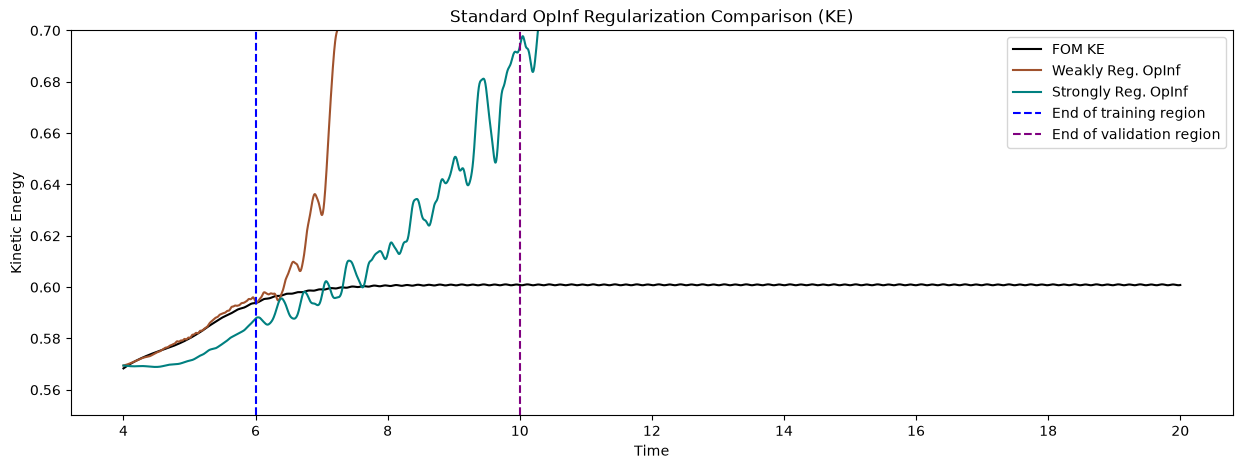

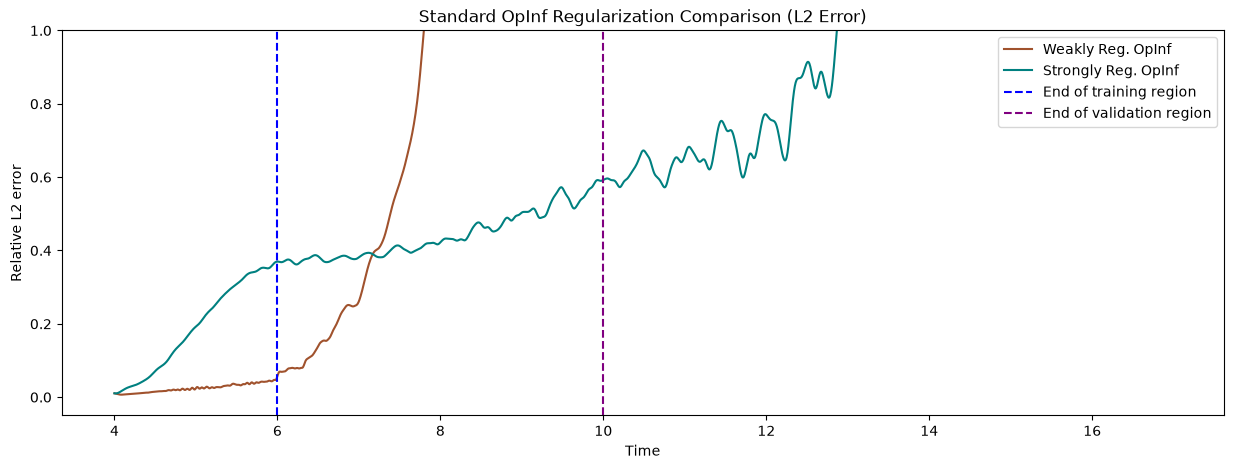

In [57]:

plot_names = {
    "optimize_model_training": "Weakly Reg. OpInf",
    "optimize_model": "Strongly Reg. OpInf",
}
filter_colors = {
    "optimize_model_training": weak_opinf_color,
    "optimize_model": strong_opinf_color,
}
fig, ax = plt.subplots(figsize=(15, 5))
any_res = next(iter(reg_results.values()))
ax.plot(any_res["FOM_KE_times"], any_res["FOM_KE"], label="FOM KE", color="black")
for name, res in reg_results.items():
    ax.plot(res["ROM_KE_times"], res["ROM_KE"], label=plot_names[name], color = filter_colors[name])
ax.axvline(x=train_times[-1], color="blue", linestyle="--", label="End of training region")
ax.axvline(x=validate_time, color="purple", linestyle="--", label="End of validation region")
ax.set_xlabel("Time"); ax.set_ylabel("Kinetic Energy")
ax.set_title("Standard OpInf Regularization Comparison (KE)")
ax.legend()
ax.set_ylim([0.55, 0.7])

fig, ax = plt.subplots(figsize=(15, 5))
for name, res in reg_results.items():
    ax.plot(res["error_times"], res["relative_L2_error"], label=plot_names[name], color = filter_colors[name])
ax.axvline(x=train_times[-1], color="blue", linestyle="--", label="End of training region")
ax.axvline(x=validate_time, color="purple", linestyle="--", label="End of validation region")
ax.set_xlabel("Time"); ax.set_ylabel("Relative L2 error")
ax.set_title("Standard OpInf Regularization Comparison (L2 Error)")
ax.legend()
ax.set_ylim([-0.05, 1.0])

In [60]:
opinf_ROM.update_model_regularization(beta1_train, beta2_train)
chi_list = np.logspace(-1, 0, 15)
#delta_list = np.logspace(-2, -1, 10)
delta_list = np.array([0.02])
r_restriction_list = [10]
selection = "last"

filter_methods = ["Projection", "Differential", "Differential_Partial"]
plot_names = {
    "Projection": "EFR-OpInf-Proj",
    "Differential": "EFR-OpInf-DF",
    "Differential_Partial": "EFR_OpInf-HDF"
}
filter_colors = {
    "Projection": projection_color,
    "Differential": differential_color,
    "Differential_Partial": diffrential_part_color,
}

print(f"EFR filter selection strategy: {selection}")

filter_results = {}

for method in filter_methods:
    base_filter_dict = {
        "filtering": True,
        "dt": dt,
        "filter_method": method,
        "basis": opinf_ROM.basis,
        "mean_func": mean_func,
        "include_mean": False,
        "fenicsx_interface": fenicsx_interface,
        "filter_time": 6.0,
    }

    best_filter_dict = opinf_ROM.optimize_EFR_validate(
        opinf_ROM.opinf_model, u0, validate_times, base_filter_dict,
        chi_list=chi_list, delta_list=delta_list, r_restriction_list=r_restriction_list,
        selection=selection,
    )
    print(f"[{method}, selection={selection}] chi={best_filter_dict['chi']:.4g}, "
          f"delta={best_filter_dict.get('delta')}, "
          f"r_restriction={best_filter_dict.get('r_restriction')}")

    solver = RK_solvers(best_filter_dict)
    res = evaluate_over_test(opinf_ROM, solver, u0, fenicsx_interface)
    res["filter_dict"] = best_filter_dict
    filter_results[method] = res

for name, res in filter_results.items():
    print(f"{name}: KE_rel_err={res['KE_rel_err']:.4e}, mean_rel_L2_err={np.mean(res['relative_L2_error']):.4e}")



EFR filter selection strategy: last
Defaulting to max growth factor of 1.2
[Projection, selection=last] chi=1, delta=None, r_restriction=10
Defaulting to max growth factor of 1.2
[Differential, selection=last] chi=1, delta=0.02, r_restriction=None
Defaulting to max growth factor of 1.2
[Differential_Partial, selection=last] chi=1, delta=0.02, r_restriction=10
Projection: KE_rel_err=2.9209e-02, mean_rel_L2_err=1.0298e-01
Differential: KE_rel_err=7.0788e-02, mean_rel_L2_err=2.6241e-01
Differential_Partial: KE_rel_err=5.1532e-03, mean_rel_L2_err=3.1000e-01


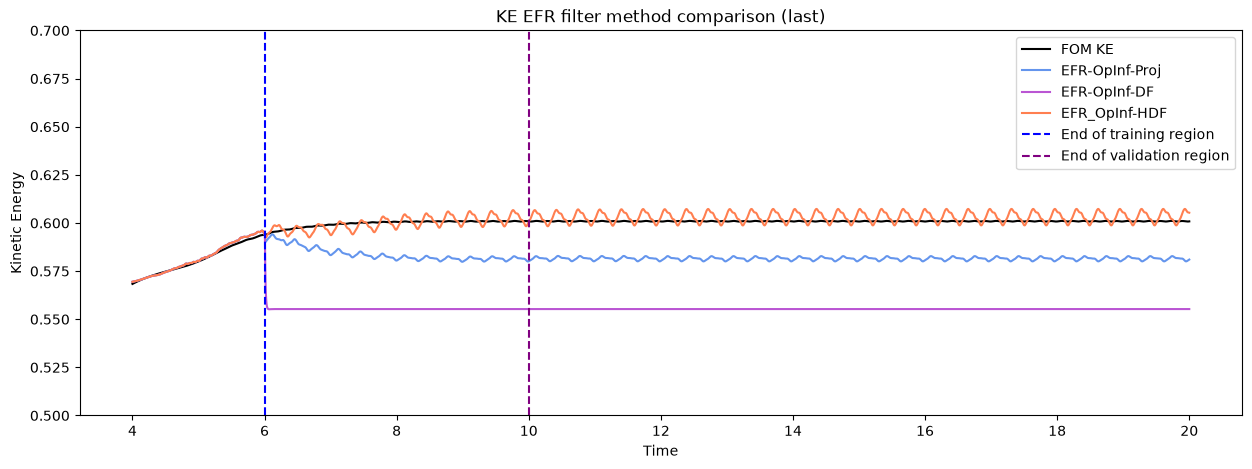

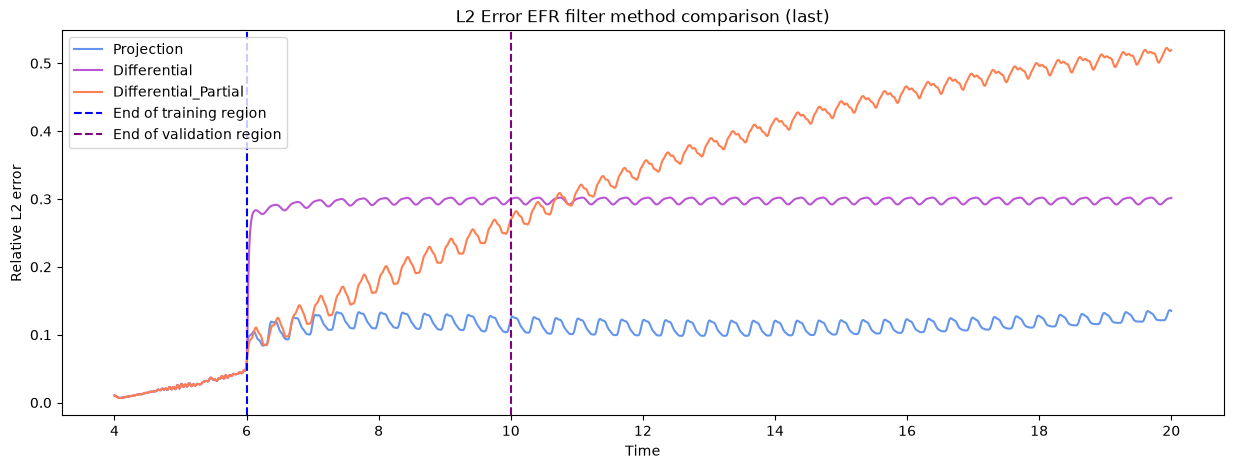

In [62]:
fig, ax = plt.subplots(figsize=(15, 5))
any_res = next(iter(filter_results.values()))
ax.plot(any_res["FOM_KE_times"], any_res["FOM_KE"], label="FOM KE", color="black")
for name, res in filter_results.items():
    ax.plot(res["ROM_KE_times"], res["ROM_KE"], label=plot_names[name], color=filter_colors[name])
ax.axvline(x=train_times[-1], color="blue", linestyle="--", label="End of training region")
ax.axvline(x=validate_time, color="purple", linestyle="--", label="End of validation region")
ax.set_xlabel("Time"); ax.set_ylabel("Kinetic Energy")
ax.set_title(f"KE EFR filter method comparison ({selection})")
ax.legend()
ax.set_ylim([0.5, 0.7])

fig, ax = plt.subplots(figsize=(15, 5))
for name, res in filter_results.items():
    ax.plot(res["error_times"], res["relative_L2_error"], label=name, color=filter_colors[name])
ax.axvline(x=train_times[-1], color="blue", linestyle="--", label="End of training region")
ax.axvline(x=validate_time, color="purple", linestyle="--", label="End of validation region")
ax.set_xlabel("Time"); ax.set_ylabel("Relative L2 error")
ax.set_title(f"L2 Error EFR filter method comparison ({selection})")
ax.legend()

## OLD STUFF

In [ ]:
# rlist = [20]
# for r in rlist:
r = 20



opinf_dict = {
    "time_start": train_start,
    "time_end": train_end,
    "validate_time": validate_time,
    "test_time": test_time,
    "r": r,
    "centering": True,
    "datapath": data_dir,
    "time_integrator": RK4_solver,
    "fenicsx_interface": fenicsx_interface
}

opinf_ROM = OpInf_ROM(opinf_dict)
if opinf_dict["centering"] == True:
    mean = opinf_ROM.transformer.mean_
    mean_func = fenicsx_interface.vector_to_func(mean)

# filtering is off here -- this cell currently compares regularization
# strength (beta1/beta2) on the raw (unfiltered) OpInf ROM. To search over
# EFR filter parameters instead, set "filtering": True and replace the
# best_filter_dict block below with a call to opinf_ROM.optimize_EFR_validate
# (see nse.py's run_nse_rom for the pattern) -- it selects chi/delta by
# stability alone, no FOM ground truth involved.
filter_dict = {"filtering": False,
            "dt": dt,
            "filter_method": "Differential_Partial",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.5,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

savefolder, identification = opinf_ROM.setup_save_folder(cwd, dt, r, filter_dict)

linear_reg = {"min": -5,
            "max": 2,
            "num":15}
quad_reg = {"min": -2,
            "max": 4,
            "num": 10}

# beta1/beta2 depend only on (dt, r, train window), never on filter choice,
# so they're cached above any filter-specific subfolder (matches the fix in
# nse.py's run_nse_rom -- this used to be cached under the (arbitrary, here
# unused) filter_dict's subfolder instead).
standard_opinf_folder = opinf_ROM._get_standard_opinf_folder(cwd, dt, r)
jsonfile = standard_opinf_folder / "optimal_reg_parameters.json"
if jsonfile.is_file():

    with open(jsonfile, 'r') as f:
        D = json.load(f)
        beta1 = D["beta1"]
        beta2 = D["beta2"]
        opinf_ROM.update_model_regularization(beta1, beta2)

else:
    opinf_ROM.optimize_model(linear_reg, quad_reg)

    beta1 = opinf_ROM.best_beta1
    beta2 =  opinf_ROM.best_beta2
    beta_dict = {"beta1": beta1,
                "beta2": beta2}
    opinf_ROM.update_model_regularization(beta1, beta2)
    with open(jsonfile, 'w') as f:
        json.dump(beta_dict, f, indent=4)

beta1 = 31
beta2 = 464
opinf_ROM.update_model_regularization(beta1, beta2)
print(f"Using regularization: Linear: {beta1}, Quadratic: {beta2}")




RK4_filter_solver = RK_solvers(filter_dict)

opinf_model = opinf_ROM.opinf_model
validate_times = opinf_ROM.validate_times
train_times = opinf_ROM.train_times
test_times = opinf_ROM.test_times

FOM_KE_times, FOM_KE = opinf_ROM.compute_FOM_KE(opinf_ROM.time_validate_idx, validate_times)

u0 = opinf_ROM.u0

Q_ROM = RK4_filter_solver.solve(opinf_model, u0, validate_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
ROM_KE_times, ROM_KE = opinf_ROM.compute_ROM_KE(ROM_sol_list, validate_times)

best_KE_err = np.linalg.norm((FOM_KE - ROM_KE))/np.linalg.norm(FOM_KE)

FOM_sol_list = opinf_ROM.fom_sol_list


L2_error, error_times = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, validate_times, ROM_sol_list, validate_times)

#### Test-region evaluation
# Used to be a manual reconstruction (t0 = predict_times[0], tf = 20.0,
# linspace...) -- that span was always identical to train_start->test_time,
# which is now just opinf_ROM.test_times directly.
test_times = opinf_ROM.test_times

t1 = time.time()
Q_ROM = RK4_filter_solver.solve(opinf_model, u0, test_times)
t2 = time.time()
print(f"EFR ROM Extended Solution time = {t2-t1}")
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
_, ROM_KE = opinf_ROM.compute_ROM_KE(ROM_sol_list, test_times, verbose = True)
ROM_KE_times = test_times

# FOM ground truth now available across the whole test horizon too (T_20
# data), not just up to validate_time, so the final comparison plot below
# can show a real FOM-vs-ROM comparison all the way out to test_time.
FOM_KE_test_times, FOM_KE_test = opinf_ROM.compute_FOM_KE(opinf_ROM.time_test_idx, test_times)




chi_list = np.logspace(-2,0,15)
delta_list = np.logspace(-2,-1,10)
best_chi = filter_dict["chi"]
best_delta = filter_dict["delta"]
KE_opt = ROM_KE
best_filter_dict = filter_dict

# To search chi_list x delta_list by stability instead of using the fixed
# chi/delta above, set filter_dict["filtering"] = True above and replace the
# five lines above with:
#
# base_filter_dict = {**filter_dict, "filtering": True}
# best_filter_dict = opinf_ROM.optimize_EFR_validate(
#     opinf_model, u0, validate_times, base_filter_dict,
#     chi_list=chi_list, delta_list=delta_list, r_restriction_list=[10],
# )

savefolder, identification = opinf_ROM.setup_save_folder(cwd, dt, r, best_filter_dict)


plot_KE(FOM_KE_test_times, ROM_KE_times, FOM_KE_test, KE_opt, train_times, savefolder, identification, validate_times = validate_times, saveROMnpz = False)

KE_npz_savepath = savefolder / ("ROM_KE_" + identification + ".npz")
#np.savez(savefolder / "FOM_KE.npz", times = FOM_KE_times, KE = FOM_KE)
# np.savez(KE_npz_savepath, times = ROM_KE_times, KE = KE_opt)


# #### LIFT/DRAG REQUIRES fenicsx_interface.setup_pressure()
# FOM_drag_arr, FOM_lift_arr, FOM_velocity_times = fenicsx_interface.compute_liftdrag(ROM_sol_list, validate_times)
# ROM_drag_arr, ROM_lift_arr, ROM_velocity_times = fenicsx_interface.compute_liftdrag(ROM_sol_list, validate_times)

# fig, ax = plt.subplots()
# ax.plot(FOM_velocity_times, FOM_drag_arr, label='FOM Drag', color='black')
# ax.plot(ROM_KE_times, ROM_drag_arr, label='OpInf Drag', color='red')
# if not np.isclose(FOM_velocity_times[-1], train_times[-1]): # means we are in predictive regime
#     last_train_time = train_times[-1]
#     ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training data')
# ax.set_xlabel('Time')
# ax.set_ylabel('Drag Coefficient')
# ax.set_title('FOM vs OpInf Drag')
# ax.legend()
# fig.savefig(savefolder / ("Opinf_" + "_drag_" + ".png") )

# fig, ax = plt.subplots()
# #ax.plot(FOM_KE_times, FOM_lift_arr, label='FOM Lift', color='black')
# ax.plot(ROM_KE_times, FOM_lift_arr - ROM_lift_arr, label='OpInf Lift', color='red')
# if not np.isclose(ROM_velocity_times[-1], train_times[-1]): # means we are in predictive regime
#     last_train_time = train_times[-1]
#     ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training data')
# ax.set_xlabel('Time')
# ax.set_ylabel('Lift Coefficient')
# ax.set_title('FOM vs OpInf Lift')
# ax.legend()
# #fig.savefig(savefolder / ("Opinf_" + "_lift_" + ".png") )

# print(np.max(ROM_lift_arr))
# print(np.allclose(ROM_lift_arr, FOM_lift_arr))

# np.savez(savefolder / ("FOM_liftdrag.npz"), times = FOM_KE_times, lift = FOM_lift_arr, drag = FOM_drag_arr)
# np.savez(savefolder / ("ROM_liftdrag_" + identification + ".npz"), times = ROM_KE_times, lift = ROM_lift_arr, drag = ROM_drag_arr)

# print(str(savefolder / ("ROM_liftdrag_" + identification + ".npz")))




# filter_comparison_filename = "Filter_comparison_" + identification + ".bp"

# opinf_ROM.compare_filter(RK4_filter_solver, 8.0, savefolder, filter_comparison_filename, filter_type = "Differential_Partial")


# basis_indices = [0,1,2,3,4,9,14,19]
# basis_comparison_filename = "Basis_Funcs" + identification + ".bp"

# opinf_ROM.save_basis_funcs(basis_indices, savefolder, basis_comparison_filename)

########## PARAVIEW VISUALIZATION


# visualization_filename = "ROM_sol_" + identification + ".bp"

# fenicsx_interface.save_function_list_VTK(ROM_sol_list, savefolder, visualization_filename, ROM_KE_times)

In [13]:
len(ROM_sol_list)

1201

In [ ]:
plt.plot(validate_times, L2_error)

In [ ]:
if filter_dict["filter_method"] == 'Projection':
    EFR_color = projection_color
    EFR_label = 'EFR-OpInf-Proj'
if filter_dict["filter_method"] == 'Differential':
    EFR_color = differential_color
    EFR_label = 'EFR-OpInf-DF'
if filter_dict["filter_method"] == 'Differential_Partial':
    EFR_color = diffrential_part_color
    EFR_label = 'EFR-OpInf-HDF'

In [ ]:
"ROM_sol" + identification + ".bp"

In [ ]:
id_safe = str(identification).replace(os.sep, "_")  # requires import os

# Build explicit filename (string form) and arrays
KE_npz_savepath = (savefolder / f"Opinf_ROM_KE_{id_safe}.npz").resolve().as_posix()
np.savez(KE_npz_savepath, KE = ROM_KE, times = ROM_KE_times)

In [ ]:
KE_npz_savepath

In [ ]:
from efr_opinf._paths import RESULTS_DIR
basedir = RESULTS_DIR / "Continuous_OpInf_Results_Quads" / "Cylinder" / "dt_0.005" / "r_20"

In [ ]:
# FOM_KE_npz = np.load(basedir / "FOM_KE.npz")
# FOM_KE = FOM_KE_npz["KE"]
# FOM_KE_times = FOM_KE_npz["times"]

FOM_KE_npz_path = data_dir / "NSE_KE_gap_10_quad_T_20.npz"
FOM_KE_npz = np.load(FOM_KE_npz_path)
FOM_KE_times = FOM_KE_npz["times"]
FOM_KE = FOM_KE_npz["KE"]


FOM_ts_idx = np.argmin(np.abs(FOM_KE_times - 4.0))

FOM_KE_times = FOM_KE_times[FOM_ts_idx:-1]
FOM_KE = FOM_KE[FOM_ts_idx:-1]


In [ ]:
weak_opinf_reg_KE_npz = np.load(basedir / 'ROM_KE__standard_reg_lin_0.1_quad_4.64.npz')

In [ ]:
weak_opinf_reg_KE = weak_opinf_reg_KE_npz["KE"]
weak_opinf_reg_times = weak_opinf_reg_KE_npz["times"]

In [ ]:
strong_opinf_reg_KE_npz = np.load(basedir / 'ROM_KE__standard_reg_lin_31_quad_464.npz')
strong_opinf_reg_KE = strong_opinf_reg_KE_npz["KE"]
strong_opinf_reg_times = strong_opinf_reg_KE_npz["times"]

In [ ]:
KE_npz_savepath

In [ ]:
#efr_opinf_reg_KE_npz = np.load( basedir / "Projection_Filtering" / "ROM_KE__filter_time_6.0_Proj_r_restriction_10_chi_0.05reg_lin_0.1_quad_4.64.npz")
efr_opinf_reg_KE_npz = np.load(KE_npz_savepath)
efr_opinf_reg_KE = efr_opinf_reg_KE_npz["times"]
efr_opinf_reg_times = efr_opinf_reg_KE_npz["KE"]


In [ ]:
efr_opinf_reg_KE_npz = np.load(KE_npz_savepath)
efr_opinf_reg_KE = efr_opinf_reg_KE_npz["times"]
efr_opinf_reg_times = efr_opinf_reg_KE_npz["KE"]

In [ ]:
fig, ax = plt.subplots()
ax.semilogy(FOM_KE_times, FOM_KE, label='FOM KE', color='black')
ax.semilogy(weak_opinf_reg_times, weak_opinf_reg_KE, label='Weak Reg. OpInf KE', color=weak_opinf_color)
ax.semilogy(strong_opinf_reg_times, strong_opinf_reg_KE, label='Strong Reg. OpInf KE', color = strong_opinf_color)
ax.semilogy(ROM_KE_times, KE_opt, label=EFR_label, color=EFR_color)

ax.set_ylim(0.5, 10**2)
if not np.isclose(weak_opinf_reg_times[-1], train_times[-1]): # means we are in predictive regime
    last_train_time = train_times[-1]
    ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_xlabel('Time')
ax.set_ylabel('Kinetic Energy')
ax.set_title('FOM vs OpInf Kinetic Energy')
ax.legend()
fig.savefig(savefolder / "OpInf_KE_Compare_logscale.png")

In [ ]:
fig, ax = plt.subplots()
ax.plot(FOM_KE_times, FOM_KE, label='FOM KE', color='black')
ax.plot(weak_opinf_reg_times, weak_opinf_reg_KE, label='Weak Reg. OpInf KE', color=weak_opinf_color)
ax.plot(strong_opinf_reg_times, strong_opinf_reg_KE, label='Strong Reg. OpInf KE', color = strong_opinf_color)
ax.plot(ROM_KE_times, KE_opt, label=EFR_label, color=EFR_color)
ax.set_ylim(0.55, 0.7)
if not np.isclose(weak_opinf_reg_times[-1], train_times[-1]): # means we are in predictive regime
    last_train_time = train_times[-1]
    ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_xlabel('Time')
ax.set_ylabel('Kinetic Energy')
ax.set_title('FOM vs OpInf Kinetic Energy')
ax.legend()
fig.savefig(savefolder / "OpInf_KE_Compare_linscale.png")

In [ ]:
fig, ax = plt.subplots()
ax.semilogy(FOM_KE_times, FOM_KE, label='FOM KE', color='black')
ax.semilogy(weak_opinf_reg_times, weak_opinf_reg_KE, label='Weak Reg. OpInf KE', color=weak_opinf_color)
ax.semilogy(strong_opinf_reg_times, strong_opinf_reg_KE, label='Strong Reg. OpInf KE', color = strong_opinf_color)

ax.set_ylim(0.5, 10**2)
if not np.isclose(weak_opinf_reg_times[-1], train_times[-1]): # means we are in predictive regime
    last_train_time = train_times[-1]
    ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_xlabel('Time')
ax.set_ylabel('Kinetic Energy')
ax.set_title('FOM vs OpInf Kinetic Energy')
ax.legend()
fig.savefig(savefolder / "standard_OpInf_KE_Compare_logscale.png")

In [ ]:
fig, ax = plt.subplots()
ax.plot(FOM_KE_times, FOM_KE, label='FOM KE', color='black')
ax.plot(weak_opinf_reg_times, weak_opinf_reg_KE, label='Weak Reg. OpInf KE', color=weak_opinf_color)
ax.plot(strong_opinf_reg_times, strong_opinf_reg_KE, label='Strong Reg. OpInf KE', color = strong_opinf_color)

ax.set_ylim(0.5, 10**2)
if not np.isclose(weak_opinf_reg_times[-1], train_times[-1]): # means we are in predictive regime
    last_train_time = train_times[-1]
    ax.axvline(x=last_train_time, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_ylim(0.55, 0.7)
ax.set_xlim(3.5,10.5)
ax.set_xlabel('Time')
ax.set_ylabel('Kinetic Energy')
ax.set_title('FOM vs OpInf Kinetic Energy')
ax.legend()
fig.savefig(savefolder / "standard_OpInf_KE_Compare_linscale.png")

In [ ]:
FOM_liftdrag_npz = np.load(basedir / "FOM_liftdrag.npz")
FOM_liftdrag_times = FOM_liftdrag_npz["times"]
FOM_drag = FOM_liftdrag_npz["drag"]
FOM_lift = FOM_liftdrag_npz['lift']

In [ ]:
weak_opinf_liftdrag_npz = np.load(basedir / "ROM_liftdrag__standard_reg_lin_0.1_quad_4.64.npz")
weak_opinf_times = weak_opinf_liftdrag_npz['times']
weak_opinf_drag = weak_opinf_liftdrag_npz['drag']
weak_opinf_lift = weak_opinf_liftdrag_npz['lift']

In [ ]:
strong_opinf_liftdrag_npz = np.load(basedir / "ROM_liftdrag__standard_reg_lin_31_quad_464.npz")
strong_opinf_times = strong_opinf_liftdrag_npz['times']
strong_opinf_drag = strong_opinf_liftdrag_npz['drag']
strong_opinf_lift = strong_opinf_liftdrag_npz['lift']

In [ ]:
efr_opinf_liftdrag_npz = np.load(basedir / "Projection_Filtering" / "ROM_liftdrag__filter_time_6.0_Proj_r_restriction_10_chi_0.05reg_lin_0.1_quad_4.64.npz")
efr_opinf_times = efr_opinf_liftdrag_npz['times']
efr_opinf_lift = efr_opinf_liftdrag_npz['lift']
efr_opinf_drag = efr_opinf_liftdrag_npz['drag']

In [ ]:
np.max(efr_opinf_lift)

In [ ]:
b.plot_residual_energy(right=30)

In [ ]:
b.cumulative_energy

In [ ]:
FOM_KE_npz_path = data_dir / "NSE_KE_gap_10_quad_T_20.npz"
FOM_KE_npz = np.load(FOM_KE_npz_path)
FOM_KE_times = FOM_KE_npz["times"]
FOM_KE_arr = FOM_KE_npz["KE"]

## L2 Errors for extended problem

In [ ]:
# This will load in extra data from T = 4 to T = 20
# This is extremely long - 30 minutes or more. I am leaving it commented to prevent unfortunate mistakes

# extended_data_file = data_fld / "NSE_snaps_gap_10_quads_T_20.bp"
# fenicsx_interface._load_extra_functions(extended_data_file, (4.0, 20.0))

# extra_FE_data = fenicsx_interface.loaded_extended_data
# extra_FE_times = fenicsx_interface.loaded_extended_times

In [ ]:
r = 20
opinf_hdf_chi = 0.05

RK4_dict = {"filtering": False,
        "dt": dt,
        }


RK4_solver = RK_solvers(RK4_dict)

opinf_dict = {
    "time_start": 4.0,
    "time_end": 6.0,
    "predict_time":10.0,
    "r": r,
    "centering": True,
    "datapath": data_dir,
    "time_integrator": RK4_solver,
    "fenicsx_interface": fenicsx_interface
}

opinf_ROM = OpInf_ROM(opinf_dict)
if opinf_dict["centering"] == True:
    mean = opinf_ROM.transformer.mean_
    mean_func = fenicsx_interface.vector_to_func(mean)

differential_partial_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential_Partial",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": opinf_hdf_chi,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Partial_Solver = RK_solvers(differential_partial_dict)

differential_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.04,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Solver = RK_solvers(differential_dict)

projection_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Projection",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.05,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Projection_Solver = RK_solvers(projection_dict)

In [ ]:
FOM_KE.shape

In [ ]:
beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)
print(f"Using regularization: Linear: {beta1}, Quadratic: {beta2}")


opinf_model = opinf_ROM.opinf_model
predict_times = opinf_ROM.predict_times
train_times = opinf_ROM.train_times

FOM_sol_list = opinf_ROM.fom_sol_list
FOM_L2_norm = fenicsx_interface.compute_solution_norm(FOM_sol_list,predict_times)

u0 = opinf_ROM.u0

Q_ROM_proj = Projection_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_proj)


ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
L2_error_proj, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
relative_L2_error_proj = L2_error_proj / FOM_L2_norm


Q_ROM_diff = Differential_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff)

ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
L2_error_diff, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
relative_L2_error_diff = L2_error_diff / FOM_L2_norm

Q_ROM_diff_par = Differential_Partial_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff_par)

ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
L2_error_diff_part, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
relative_L2_error_diff_part = L2_error_diff_part / FOM_L2_norm


In [ ]:
beta1 = 31
beta2 = 464
opinf_ROM.update_model_regularization(beta1, beta2)


u0 = opinf_ROM.u0
Q_ROM = RK4_solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

opinf_basic_L2_error, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
relative_L2_error_basic_opinf = opinf_basic_L2_error / FOM_L2_norm


In [ ]:
beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)


u0 = opinf_ROM.u0
Q_ROM = RK4_solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

weak_opinf_basic_L2_error, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
relative_L2_error_weak_basic_opinf = weak_opinf_basic_L2_error / FOM_L2_norm

In [ ]:
from efr_opinf._paths import RESULTS_DIR
basedir = RESULTS_DIR / "Continuous_OpInf_Results_Quads" / "Cylinder" / "dt_0.005" / "r_20"
savepath = basedir / f"Opinf_L2_Errors_Compare_hdf_chi_{opinf_hdf_chi}.png"

In [ ]:
fig, ax = plt.subplots()
ax.semilogy(predict_times, relative_L2_error_basic_opinf, label='Strong Reg. OpInf', color = strong_opinf_color)
ax.semilogy(predict_times, relative_L2_error_weak_basic_opinf, label='Weak Reg. OpInf', color = weak_opinf_color)
ax.semilogy(predict_times, relative_L2_error_proj, label='EFR-OpInf-Proj', color=projection_color)
ax.semilogy(predict_times, relative_L2_error_diff, label='EFR-OpInf-DF', color=differential_color)
ax.semilogy(predict_times, relative_L2_error_diff_part, label='EFR-OpInf-HDF', color=diffrential_part_color)

ax.set_ylim(1e-5, 10)
ax.axvline(x=6.0, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_xlabel('Time')
ax.set_ylabel(r'Relative L^2 Error')
ax.set_title(r'OpInf and EFR-OpInf Relative $L^2$ Errors')
ax.legend()
fig.savefig(savepath)

In [ ]:
FOM_KE_npz_path = data_dir / "NSE_KE_gap_10_quad_T_20.npz"
FOM_KE_npz = np.load(FOM_KE_npz_path)
FOM_KE_times = FOM_KE_npz["times"]
FOM_KE = FOM_KE_npz["KE"]


FOM_ts_idx = np.argmin(np.abs(FOM_KE_times - 4.0))
FOM_te_idx = np.argmin(np.abs((FOM_KE_times - predict_times[-1])))

FOM_KE_times = FOM_KE_times[FOM_ts_idx:FOM_te_idx +1]
FOM_KE = FOM_KE[FOM_ts_idx:FOM_te_idx+1]

In [ ]:
r = 20
opinf_hdf_chi = 0.7

RK4_dict = {"filtering": False,
        "dt": dt,
        }


RK4_solver = RK_solvers(RK4_dict)

opinf_dict = {
    "time_start": 4.0,
    "time_end": 6.0,
    "predict_time":10.0,
    "r": r,
    "centering": True,
    "datapath": data_dir,
    "time_integrator": RK4_solver,
    "fenicsx_interface": fenicsx_interface
}

opinf_ROM = OpInf_ROM(opinf_dict)
if opinf_dict["centering"] == True:
    mean = opinf_ROM.transformer.mean_
    mean_func = fenicsx_interface.vector_to_func(mean)

differential_partial_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential_Partial",
            "r_restriction": 10,
            "delta": 0.02,
            "chi":opinf_hdf_chi,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Partial_Solver = RK_solvers(differential_partial_dict)

differential_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.04,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Solver = RK_solvers(differential_dict)

projection_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Projection",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.05,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Projection_Solver = RK_solvers(projection_dict)

In [ ]:
beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)
print(f"Using regularization: Linear: {beta1}, Quadratic: {beta2}")


opinf_model = opinf_ROM.opinf_model
predict_times = opinf_ROM.predict_times
train_times = opinf_ROM.train_times

u0 = opinf_ROM.u0

Q_ROM_proj = Projection_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_proj)


ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
ROM_KE_times, ROM_KE_proj = opinf_ROM.compute_ROM_KE(ROM_sol_list)
ke_proj_arr = np.abs(FOM_KE - ROM_KE_proj) / FOM_KE


Q_ROM_diff = Differential_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff)

ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
ROM_KE_times, ROM_KE_diff = opinf_ROM.compute_ROM_KE(ROM_sol_list)
ke_diff_arr = np.abs(FOM_KE - ROM_KE_diff) / FOM_KE

Q_ROM_diff_par = Differential_Partial_Solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff_par)

ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

ROM_KE_times, ROM_KE_diff_part = opinf_ROM.compute_ROM_KE(ROM_sol_list)
ke_diff_part_arr = np.abs(FOM_KE - ROM_KE_diff_part) / FOM_KE


In [ ]:
beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)


u0 = opinf_ROM.u0
Q_ROM = RK4_solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

ROM_KE_times, ROM_KE_weak = opinf_ROM.compute_ROM_KE(ROM_sol_list)
ke_weak_arr = np.abs(FOM_KE - ROM_KE_weak) / FOM_KE

In [ ]:
beta1 = 31
beta2 = 464
opinf_ROM.update_model_regularization(beta1, beta2)


u0 = opinf_ROM.u0
Q_ROM = RK4_solver.solve(opinf_model, u0, predict_times)
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)

ROM_KE_times, ROM_KE_strong = opinf_ROM.compute_ROM_KE(ROM_sol_list)
ke_strong_arr = np.abs(FOM_KE - ROM_KE_strong) / FOM_KE


In [ ]:
from efr_opinf._paths import RESULTS_DIR
basedir = RESULTS_DIR / "Continuous_OpInf_Results_Quads" / "Cylinder" / "dt_0.005" / "r_20"
savepath = basedir / f"Opinf_KE_Compare_hdf_chi_{opinf_hdf_chi}.png"

In [ ]:
fig, ax = plt.subplots()
ax.plot(predict_times, FOM_KE, label = 'FOM', color = 'black')
ax.plot(predict_times, ROM_KE_strong, label='Strong Reg. OpInf', color = strong_opinf_color)
ax.plot(predict_times, ROM_KE_weak, label='Weak Reg. OpInf', color = weak_opinf_color)
ax.plot(predict_times, ROM_KE_proj, label='EFR-OpInf-Proj', color=projection_color)
ax.plot(predict_times, ROM_KE_diff, label='EFR-OpInf-DF', color=differential_color)
ax.plot(predict_times, ROM_KE_diff_part, label='EFR-OpInf-HDF', color=diffrential_part_color)

ax.set_ylim(0.55, 0.7)
ax.axvline(x=6.0, color='blue', linestyle='--', label='End of training region')
ax.axvline(x = 10.0, color='purple', linestyle = '--', label = 'End of validation region')
ax.set_xlabel('Time')
ax.set_ylabel(r'KE')
ax.set_title(r'OpInf and EFR-OpInf KE')
ax.legend()
fig.savefig(savepath)


## Pareto Plots / Timing

In [ ]:
r = 20


RK4_dict = {"filtering": False,
        "dt": dt,
        }


RK4_solver = RK_solvers(RK4_dict)

opinf_dict = {
    "time_start": 4.0,
    "time_end": 6.0,
    "predict_time":10.0,
    "r": r,
    "centering": True,
    "datapath": data_dir,
    "time_integrator": RK4_solver,
    "fenicsx_interface": fenicsx_interface
}

opinf_ROM = OpInf_ROM(opinf_dict)
if opinf_dict["centering"] == True:
    mean = opinf_ROM.transformer.mean_
    mean_func = fenicsx_interface.vector_to_func(mean)

differential_partial_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential_Partial",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 1.0,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Partial_Solver = RK_solvers(differential_partial_dict)

differential_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Differential",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.01,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Differential_Solver = RK_solvers(differential_dict)

projection_dict = {"filtering": True,
            "dt": dt,
            "filter_method": "Projection",
            "r_restriction": 10,
            "delta": 0.02,
            "chi": 0.01,
            "basis": opinf_ROM.basis,
            "mean_func": mean_func,
            "include_mean": False,
            "fenicsx_interface": fenicsx_interface,
            "filter_time": 6.0}

Projection_Solver = RK_solvers(projection_dict)


beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)
print(f"Using regularization: Linear: {beta1}, Quadratic: {beta2}")
# opinf_ROM.update_model_regularization(0.03162277660168379, 1.0)

solver_list = [Differential_Partial_Solver, Differential_Solver, Projection_Solver]

FOM_KE_times, FOM_KE = opinf_ROM.compute_FOM_KE()

In [ ]:
beta1 = 0.1
beta2 = 4.64
opinf_ROM.update_model_regularization(beta1, beta2)
print(f"Using regularization: Linear: {beta1}, Quadratic: {beta2}")
# opinf_ROM.update_model_regularization(0.03162277660168379, 1.0)
#chi_list = [1.0]
chi_list = [0.005, 0.01, 0.015, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
#chi_list = [0.5,0.6,0.7,0.8,0.9,1.0]





opinf_model = opinf_ROM.opinf_model
predict_times = opinf_ROM.predict_times
train_times = opinf_ROM.train_times

FOM_sol_list = opinf_ROM.fom_sol_list
FOM_L2_norm = fenicsx_interface.compute_solution_norm(FOM_sol_list, predict_times)


proj_error_arr = np.zeros_like(chi_list)
proj_error_times = np.zeros_like(chi_list)
proj_ke_arr = np.zeros_like(chi_list)

diff_error_arr = np.zeros_like(chi_list)
diff_error_times = np.zeros_like(chi_list)
diff_ke_arr = np.zeros_like(chi_list)

diff_part_error_arr = np.zeros_like(chi_list)
diff_part_error_times = np.zeros_like(chi_list)
diff_part_ke_arr = np.zeros_like(chi_list)

import time

for i, chi in enumerate(tqdm(chi_list)):

    for solver in solver_list:
        solver.update_chi_only(chi)

    u0 = opinf_ROM.u0

    t1 = time.time()
    Q_ROM_proj = Projection_Solver.solve(opinf_model, u0, predict_times)
    t2 = time.time()
    recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_proj)


    ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
    ROM_KE_times, ROM_KE_proj = opinf_ROM.compute_ROM_KE(ROM_sol_list)
    L2_error_proj, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)

    proj_ke_arr[i] = np.mean( np.abs(FOM_KE - ROM_KE_proj) / FOM_KE)
    proj_error_arr[i] = np.mean(L2_error_proj / FOM_L2_norm)
    proj_error_times[i] = (t2-t1)
    

    t1 = time.time()
    Q_ROM_diff = Differential_Solver.solve(opinf_model, u0, predict_times)
    t2 = time.time()
    recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff)
    
    ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
    ROM_KE_times, ROM_KE_diff = opinf_ROM.compute_ROM_KE(ROM_sol_list)
    L2_error, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)

    diff_ke_arr[i] = np.mean( np.abs(FOM_KE - ROM_KE_diff) / FOM_KE)
    diff_error_arr[i] = np.mean(L2_error / FOM_L2_norm)
    diff_error_times[i] = (t2-t1)
    
    t1 = time.time()
    Q_ROM_diff_par = Differential_Partial_Solver.solve(opinf_model, u0, predict_times)
    t2 = time.time()
    recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM_diff_par)
    
    ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
    ROM_KE_times, ROM_KE_diff_part = opinf_ROM.compute_ROM_KE(ROM_sol_list)
    L2_error, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)

    diff_part_ke_arr[i] = np.mean( np.abs(FOM_KE - ROM_KE_diff_part) / FOM_KE)
    diff_part_error_arr[i] = np.mean(L2_error / FOM_L2_norm)
    diff_part_error_times[i] = (t2-t1)





In [ ]:
beta1 = 31
beta2 = 464
opinf_ROM.update_model_regularization(beta1, beta2)
best_times = 10
total_times = 0.0
for i in range(10):
    u0 = opinf_ROM.u0
    t1 = time.time()
    Q_ROM = RK4_solver.solve(opinf_model, u0, predict_times)
    t2 = time.time()
    opinf_time = t2 - t1
    total_times += opinf_time
    if opinf_time < best_times:
        best_times = opinf_time

opinf_time = best_times
opinf_time = total_times / 10.
recon_data = opinf_ROM.reconstruct_ROM_sol(Q_ROM)
ROM_sol_list = opinf_ROM.convert_lumped_data_to_FE_function_list(recon_data)
ROM_KE_times, ROM_KE = opinf_ROM.compute_ROM_KE(ROM_sol_list)

opinf_basic_KE_error = np.mean( np.abs(FOM_KE - ROM_KE) / FOM_KE)
opinf_basic_L2_error, _ = fenicsx_interface.compute_pointwise_errors(FOM_sol_list, predict_times, ROM_sol_list, predict_times)
opinf_basic_mean_error = np.mean(opinf_basic_L2_error / FOM_L2_norm)


In [ ]:
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
import matplotlib as mpl
def pareto_plot_time_vs_error(chi_list,
                               proj_error_arr, proj_error_times,
                               diff_error_arr, diff_error_times,
                               diff_part_error_arr, diff_part_error_times,
                               opinf_basic_mean_error, opinf_time, KE = False,
                               savepath=None):
    
    # Convert inputs to numpy arrays
    chi = np.asarray(chi_list, dtype=float)
    proj_err = np.asarray(proj_error_arr, dtype=float)
    proj_t   = np.asarray(proj_error_times, dtype=float)
    diff_err = np.asarray(diff_error_arr, dtype=float)
    diff_t   = np.asarray(diff_error_times, dtype=float)
    dpart_err = np.asarray(diff_part_error_arr, dtype=float)
    dpart_t   = np.asarray(diff_part_error_times, dtype=float)

    # Basic sanity checks
    n = chi.size
    if not (proj_err.size == proj_t.size == n and
            diff_err.size == diff_t.size == n and
            dpart_err.size == dpart_t.size == n):
        raise ValueError("All error/time arrays must have the same length as chi_list")

    # Colormap / normalization for chi
    cmap = plt.cm.viridis
    norm = mcolors.LogNorm(vmin=chi.min(), vmax=chi.max())
    #norm = plt.Normalize(vmin=chi.min(), vmax=chi.max())

    fig, ax = plt.subplots(figsize=(8,6))

    


    # helper to plot a model, masking NaNs/infs
    def _scatter_model(times, errs, marker, label, edgecolor='k', s=90, alpha=0.9):
        mask = np.isfinite(times) & np.isfinite(errs)
        if np.any(mask):
            sc = ax.scatter(times[mask], errs[mask],
                            c=chi[mask], cmap=cmap, norm=norm,
                            marker=marker, s=s, edgecolors=edgecolor, linewidths=0.6,
                            alpha=alpha, label=label)
            return sc
        return None

    sc1 = _scatter_model(proj_t, proj_err, marker='o', label='EFR-OpInf-Proj')
    sc2 = _scatter_model(diff_t, diff_err, marker='s', label='EFR-OpInf-DF')
    sc3 = _scatter_model(dpart_t, dpart_err, marker='^', label='EFR-OpInf-HDF')

    # Plot baseline OpInf point
    ax.scatter([opinf_time], [opinf_basic_mean_error], marker='x', color=strong_opinf_color,
               s=220, label='OpInf baseline')
    
    ax.set_yscale('log')
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label(r'Filter parameter $\chi$')

    cbar.locator = mticker.LogLocator(base=10.0) 
    cbar.update_ticks()
    cbar.ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3g'))  # or '%.2f' etc.
    
    if KE:
        ylabel = 'Mean Kinetic Energy Relative Error'
        title = 'Mean Relative KE Error vs. Compute Time'
    else:  
        ylabel = 'Mean Relative $L^2$ error'
        title = 'Mean Relative $L^2$ Error vs Compute Time'

    # Axes labels / title / grid
    ax.set_xlabel('Wall-clock time (s)')   # adjust units label if appropriate
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(alpha=0.3)

    # sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
    # sm.set_array(chi)  # for colorbar; some matplotlib versions require set_array
    # cbar = fig.colorbar(sm, ax=ax)
    # cbar.set_label(r'Filter parameter $\chi$')

    # Legend (avoid duplicate entries if any scatter returned None)
    ax.legend(loc='best', frameon=True)

    # Optionally save figure and/or return handles
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

    plt.show()
    return fig, ax, (sc1, sc2, sc3, sm)

In [ ]:
from efr_opinf._paths import RESULTS_DIR
basedir = RESULTS_DIR / "Continuous_OpInf_Results_Quads" / "Cylinder" / "dt_0.005" / "r_20"

In [ ]:
#savepath = basedir / 'EFR_OpInf_Pareto_KE_vary_chi_all_NEW_Filter_Method.png'
fig, ax, handles = pareto_plot_time_vs_error(chi_list,
                                             proj_ke_arr, proj_error_times,
                                             diff_ke_arr, diff_error_times,
                                             diff_part_ke_arr, diff_part_error_times,
                                             opinf_basic_KE_error, opinf_time, KE = True,
                                             savepath=None)

In [ ]:
savepath = basedir / 'EFR_OpInf_Pareto_L2_vary_chi_all_NEW_Filter_Method.png'
fig, ax, handles = pareto_plot_time_vs_error(chi_list,
                                             proj_error_arr, proj_error_times,
                                             diff_error_arr, diff_error_times,
                                             diff_part_error_arr, diff_part_error_times,
                                             opinf_basic_mean_error, opinf_time, KE = False,
                                             savepath=savepath)

In [ ]:
savepath

In [ ]:
diff_error_arr[4:].min()*100

In [ ]:
diff_ke_arr[4:].var()*100

In [ ]:
diff_part_error_arr[1:].var()*100

In [ ]:
diff_part_ke_arr[1:].min()*100

In [ ]:
a = np.nanargmin(proj_ke_arr)

In [ ]:
chi_list[a]

In [ ]:
diff_part_error_arr[-1]*100